# 06 — PCA(0.90) + KNN  (the cautionary tale)

This notebook trains the **original** PCA + KNN pipeline
that scored only ~0.515 accuracy. The reason will be
visible in the cell that prints `pca.n_components_`: PCA
retains exactly **1 component** for 90% variance, because
the outlier-dominated nutrition columns hijack the
projection. KNN is then asked to do similarity search on a
1-D projection of the data. See README §4 Lesson #5.

The **fix** for this is in
`07_PCA_KNN_Improved.ipynb`.

## 1 — Setup

Configure matplotlib for inline rendering, add the project
root to `sys.path` so we can import from `src/`, and pull in
the shared helpers + the project-wide `RANDOM_STATE = 42`.

In [1]:
%matplotlib inline
import sys
from pathlib import Path

# `notebooks/` is one level below the project root; add the
# project root so `from src import ...` resolves correctly.
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src import (
    RANDOM_STATE,
    DATASETS,
    load_preprocessed,
    fit_and_score,
    build_metrics_payload,
    save_metrics,
    save_predictions,
    save_figure,
    confusion_matrix_figure,
    roc_curve_figure,
    print_dataset_block,
    print_delta,
    model_results_dir,
)

print(f"RANDOM_STATE = {RANDOM_STATE} (single source of truth in src.train_utils)")

RANDOM_STATE = 42 (single source of truth in src.train_utils)


## 2 — Load the preprocessed feature matrices

`load_preprocessed()` returns the two parallel matrices
produced by Phase 1: the **Baseline** (nutrition + tags only)
and the **Advanced** (Baseline + 9 engineered culinary
features). Both share the same train/test partition so the
A/B comparison is apples-to-apples.

In [2]:
datasets, y_train, y_test = load_preprocessed()

print(f"Baseline X_train: {datasets['Baseline'][0].shape}")
print(f"Advanced X_train: {datasets['Advanced'][0].shape}")
print(f"y_test class balance: Miss={int((y_test == 0).sum())} / "
      f"Hit={int((y_test == 1).sum())} "
      f"(majority-class rate: {max(y_test.mean(), 1 - y_test.mean()):.4f})")

Baseline X_train: (14578, 678)
Advanced X_train: (14578, 687)
y_test class balance: Miss=1698 / Hit=1947 (majority-class rate: 0.5342)


## 3 — Configure the pipeline

`PCA(n_components=0.90)` keeps the smallest set of
principal components that together retain 90% of the input
variance. `KNN(n_neighbors=5)` operates in that reduced
space. Both stages share the same `random_state`. KNN
itself is deterministic (no random_state to set).

In [3]:
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline

MODEL_SLUG    = "pca_knn"
MODEL_NAME    = "PCA(0.90) + KNN"
DISPLAY_NAME  = "PCA(0.90) + KNN"

PCA_VARIANCE = 0.90
KNN_NEIGHBORS = 5
MODEL_CONFIG = {
    "pca": {"n_components": PCA_VARIANCE, "random_state": RANDOM_STATE},
    "knn": {"n_neighbors": KNN_NEIGHBORS, "n_jobs": -1},
}

def _build_model():
    return Pipeline(steps=[
        ("pca", PCA(**MODEL_CONFIG["pca"])),
        ("knn", KNeighborsClassifier(**MODEL_CONFIG["knn"])),
    ])
MODEL_CONFIG

{'pca': {'n_components': 0.9, 'random_state': 42},
 'knn': {'n_neighbors': 5, 'n_jobs': -1}}

## 4 — Train and capture `pca.n_components_`

We extract the actual number of components PCA retained.
On this dataset it's exactly **1** — see the diagnostic
below.

In [4]:
per_ds_results = {}
pca_components_per_dataset = {}

for ds_name in DATASETS:
    X_train, X_test = datasets[ds_name]
    model = _build_model()
    result = fit_and_score(model, X_train, y_train, X_test, y_test)
    per_ds_results[ds_name] = result

    pca_stage = result["model"].named_steps["pca"]
    n_components = int(pca_stage.n_components_)
    pca_components_per_dataset[ds_name] = n_components

    print_dataset_block(ds_name, X_train.shape, result)
    print(f"     PCA components retained for 90% variance : {n_components}")
    save_predictions(MODEL_SLUG, ds_name, result["y_pred"])

print_delta(per_ds_results)
display(pd.Series(pca_components_per_dataset, name="components retained at 90% variance").to_frame())


  --- Baseline  (X_train: (14578, 678)) ---
     Test Accuracy : 0.5147
     Test F1-Score : 0.5565
     Confusion Matrix:
                       Pred:Miss  Pred:Hit
        True:Miss          766       932   FP rate = 0.5489
        True:Hit           837      1110   FN rate = 0.4299
     PCA components retained for 90% variance : 1

  --- Advanced  (X_train: (14578, 687)) ---
     Test Accuracy : 0.5133
     Test F1-Score : 0.5578
     Confusion Matrix:
                       Pred:Miss  Pred:Hit
        True:Miss          752       946   FP rate = 0.5571
        True:Hit           828      1119   FN rate = 0.4253
     PCA components retained for 90% variance : 1

  >> Δ (Advanced − Baseline):  Acc -0.0014  |  F1 +0.0013


,components retained at 90% variance
Baseline,1
Advanced,1


## 5 — Confusion matrix (Advanced fit)

Annotated heatmap of the Advanced-fit confusion matrix.
Rendered inline AND persisted to
`results/<slug>/confusion_matrix.png`.

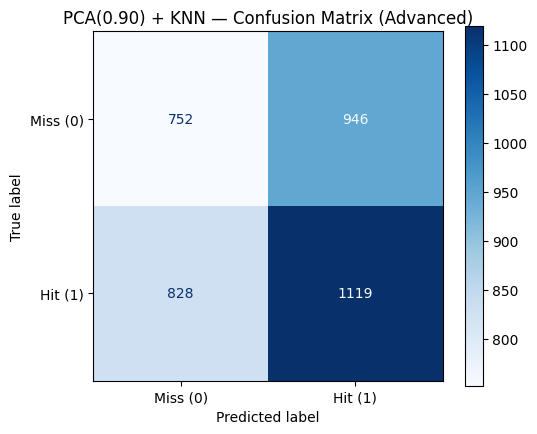

In [5]:
adv = per_ds_results["Advanced"]
cm_array = np.array([
    [adv["confusion_matrix"]["tn"], adv["confusion_matrix"]["fp"]],
    [adv["confusion_matrix"]["fn"], adv["confusion_matrix"]["tp"]],
])
fig_cm = confusion_matrix_figure(
    cm_array,
    title=f"{DISPLAY_NAME} — Confusion Matrix (Advanced)",
)
save_figure(MODEL_SLUG, "confusion_matrix.png", fig_cm)
plt.show()

## 6 — ROC curve + AUC (Advanced fit)

Generated against `predict_proba` (or `decision_function`
where probabilities aren't available). The AUC is the
ranking-quality summary independent of any threshold choice;
Phase 4's threshold-sweep work depends on it.

Test ROC AUC (Advanced): 0.5161


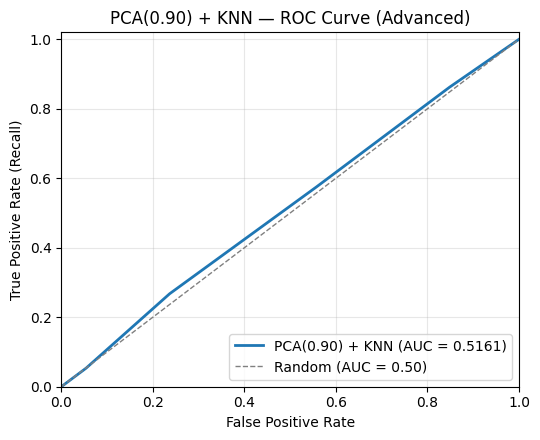

In [6]:
fig_roc, auc = roc_curve_figure(
    y_test, adv["proba_hit"],
    title=f"{DISPLAY_NAME} — ROC Curve (Advanced)",
    model_label=DISPLAY_NAME,
)
save_figure(MODEL_SLUG, "roc_curve.png", fig_roc)
print(f"Test ROC AUC (Advanced): {auc:.4f}")
plt.show()

## 8 — Persist the canonical metrics JSON

One JSON per model, written to
`results/<slug>/metrics.json`. Schema is defined in
`src.train_utils.build_metrics_payload`; the master
comparison notebook reads from here.

In [7]:
extras = {
    "pca_components_retained": pca_components_per_dataset,
    "pca_variance_threshold":  PCA_VARIANCE,
    "knn_n_neighbors":         KNN_NEIGHBORS,
    "roc_auc_advanced":        auc,
}

payload = build_metrics_payload(
    model_name=MODEL_NAME,
    display_name=DISPLAY_NAME,
    model_config=MODEL_CONFIG,
    n_train=len(y_train),
    n_test=len(y_test),
    random_state=RANDOM_STATE,
    per_dataset_results=per_ds_results,
    extras=extras,
)
metrics_path = save_metrics(MODEL_SLUG, payload)
print(f"Wrote {metrics_path.relative_to(metrics_path.parent.parent.parent)}")

Wrote results/pca_knn/metrics.json


## 9 — Summary

    **Model:** PCA(0.90) + KNN  (the cautionary tale)

    - **Test Accuracy / F1:** ~0.5133 / ~0.5578 — barely above the
  0.534 majority-class rate.
- **PCA retained 1 component** — the diagnostic that motivated
  `07_PCA_KNN_Improved.ipynb`.
- **Lesson:** capture structural diagnostics before reasoning
  from theory alone (README §4 Lesson #5).

    Run the **master comparison notebook
    (`08_Master_Comparison.ipynb`)** to see this model alongside
    the other six in the side-by-side table.